# Solving Linear Systems with Message Passing

Most of us solve $Ax=b$ with a direct linear-algebra routine. In this tutorial we take a more scenic route: every unknown becomes a node in a graph, every nonzero off-diagonal entry becomes a coupling, and local Gaussian messages cooperate to recover the solution.

This is useful beyond solving one small system. The graph view exposes sparsity, supports distributed computation, and gives us a live view of convergence. It also reveals a subtle behavior: on graphs with cycles the means can be exact even when the reported variances are not.

In [1]:
using LinearAlgebra
using Plots
using Random
using ReactiveMP
using RxInfer
using StableRNGs
using OneHotArrays

default(; linewidth = 2, markersize = 5, legend = :best)

## A linear system as a Gaussian model

Assume that $A$ is symmetric and positive definite. The unnormalized Gaussian

$$p(x) \propto \exp\left(-\frac{1}{2}x^\mathsf{T}Ax+b^\mathsf{T}x\right)$$

has mean $A^{-1}b$, so finding its mean solves $Ax=b$. Expanding the exponent gives two kinds of factor:

- an univiariate Normal distribution for each diagonal entry $\exp(b_ix_i - \frac{1}{2} x_i^2A_{ii})$;
- an edge potential $\exp(-A_{ij}x_i x_j)$ for each nonzero off-diagonal entry.

The `GaussianCoupling` node represents exactly that edge potential: `GaussianCoupling(xᵢ, -A[i, j])`.

In [2]:
@model function linear_system_model(b, A)
    n = length(b)

    # exp(bᵢxᵢ - Aᵢᵢxᵢ²/2), written as an ordinary normalized Gaussian.
    for i in 1:n
        x[i] ~ Normal(mean = b[i] / A[i, i], precision = A[i, i])
    end

    # One GaussianCoupling factor for every edge of the sparse matrix.
    for i in 1:(n - 1), j in (i + 1):n
        if !iszero(A[i, j])
            x[j] ~ GaussianCoupling(x[i], -A[i, j])
        end
    end
end

The graph can contain feedback loops, so it needs an initial message before updates can circulate. We start with a broad Gaussian message. This is only a computational starting point; it is not an extra prior in the model. `KeepEach()` records the belief after every sweep so that we can watch the algorithm settle.

In [3]:
function solve_with_messages(A, b; iterations = 20)
    @assert issymmetric(A) "A must be symmetric"
    @assert isposdef(A) "A must be positive definite"

    initialization = @initialization begin
        μ(x) = NormalMeanVariance(0.0, 1e6)
    end

    result = infer(
        model = linear_system_model(A = A),
        data = (b = b,),
        initialization = initialization,
        returnvars = (x = KeepEach(),),
        iterations = iterations,
        options = (limit_stack_depth = 100,),   # keeps large graphs from exhausting the stack
    )

    beliefs = result.posteriors[:x]
    means = reduce(hcat, (mean.(belief) for belief in beliefs))
    variances = reduce(hcat, (var.(belief) for belief in beliefs))
    return (; result, beliefs, means, variances)
end

solve_with_messages (generic function with 1 method)

## Warm-up: a chain

First consider four unknowns coupled in a chain. The corresponding factor graph has no cycles. This is the friendly case: both the means and marginal variances returned by message passing are exact.

In [4]:
A_tree = [
    3.0  -0.8   0.0   0.0
   -0.8   3.5  -0.6   0.0
    0.0  -0.6   2.8  -0.7
    0.0   0.0  -0.7   2.5
]
b_tree = [1.0, -0.5, 2.0, 0.75]
tree = solve_with_messages(A_tree, b_tree; iterations = 12)

x_exact_tree = A_tree \ b_tree
v_exact_tree = diag(inv(A_tree))

println("largest mean error:     ", maximum(abs.(tree.means[:, end] - x_exact_tree)))
println("largest variance error: ", maximum(abs.(tree.variances[:, end] - v_exact_tree)))

largest mean error:     2.220446049250313e-16
largest variance error: 5.551115123125783e-17


Before looking at the numbers, look at the graph itself. Circles are unknowns, the small dark squares are the Gaussian self-potentials, and every `A` square is one `GaussianCoupling` factor sitting on a nonzero off-diagonal entry of $A$. For the chain there is exactly one path between any two unknowns: no loops, so message passing is exact in every respect. The picture at the bottom explains how to convert an A into the respective factor graph.

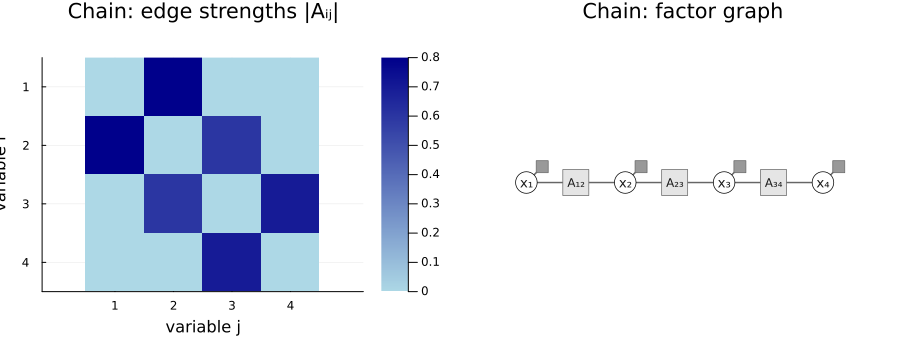

In [6]:
# A picture of the factor graph itself, drawn directly with Plots so it composes with
# other subplots: a circle per unknown, a labelled square per `GaussianCoupling` factor (one for
# every nonzero off-diagonal of A), and a small dark square for each Gaussian
# self-potential. The double loop mirrors `linear_system_model` line by line.
function factor_graph(A; positions, kwargs...)
    n = size(A, 1)
    sub(k) = join('₀' + d for d in reverse(digits(k)))
    selfpos = [p .+ (0.16, 0.16) for p in positions]

    xs = [first.(positions); first.(selfpos)]
    ys = [last.(positions); last.(selfpos)]
    p = plot(;
        legend = false, axis = false, grid = false, ticks = false, aspect_ratio = :equal,
        xlims = extrema(xs) .+ (-0.5, 0.5), ylims = extrema(ys) .+ (-0.5, 0.5), kwargs...
    )

    # Edges first, so that the nodes are drawn on top of them.
    for i in 1:n
        plot!(p, [positions[i][1], selfpos[i][1]], [positions[i][2], selfpos[i][2]]; color = :gray40, linewidth = 1.5)
    end
    for i in 1:(n - 1), j in (i + 1):n
        if !iszero(A[i, j])
            plot!(p, [positions[i][1], positions[j][1]], [positions[i][2], positions[j][2]]; color = :gray40, linewidth = 1.5)
        end
    end

    # A labelled square per `GaussianCoupling` factor, halfway along its edge.
    for i in 1:(n - 1), j in (i + 1):n
        if !iszero(A[i, j])
            mid = (positions[i] .+ positions[j]) ./ 2
            scatter!(p, [mid[1]], [mid[2]]; marker = :square, markersize = 13, color = :gray90, markerstrokecolor = :gray40)
            annotate!(p, mid[1], mid[2], text("A$(sub(i))$(sub(j))", 8, :gray10))
        end
    end

    # A small dark square per Gaussian self-potential and a circle per unknown.
    scatter!(p, first.(selfpos), last.(selfpos); marker = :square, markersize = 6, color = :gray60, markerstrokecolor = :gray40)
    scatter!(p, first.(positions), last.(positions); marker = :circle, markersize = 12, color = :white, markerstrokecolor = :black)
    for i in 1:n
        annotate!(p, positions[i][1], positions[i][2], text("x$(sub(i))", 9, :gray10))
    end
    return p
end

fg = factor_graph(A_tree; positions = [(float(i), 0.0) for i in 1:4], title = "Chain: factor graph");

p_tree_graph = heatmap(
    abs.(A_tree .- Diagonal(diag(A_tree))),
    title = "Chain: edge strengths |Aᵢⱼ|",
    xlabel = "variable j", ylabel = "variable i",
    aspect_ratio = :equal, color = :blues, yflip = true, xticks = 1:4, yticks = 1:4,
);

plot(p_tree_graph, fg; layout = (1, 2), size = (900, 360))

## Add one edge: a loopy graph

Closing the chain into a ring creates a feedback loop. We keep the matrix strictly diagonally dominant, a convenient sufficient condition for convergence. Watch what changes: the means still converge to `A \ b`, while the variances become loop-dependent approximations.

In [7]:
A_loop = copy(A_tree)
A_loop[1, 4] = A_loop[4, 1] = -0.9
loop = solve_with_messages(A_loop, b_tree; iterations = 20)

x_exact_loop = A_loop \ b_tree
v_exact_loop = diag(inv(A_loop))
residuals = [norm(A_loop * loop.means[:, k] - b_tree) for k in axes(loop.means, 2)]

@assert all(A_loop[i, i] > sum(abs, A_loop[i, :]) - A_loop[i, i] for i in axes(A_loop, 1))
println("final residual ‖Ax-b‖: ", residuals[end])

final residual ‖Ax-b‖: 1.6965719047317644e-14


Here is what that one extra matrix entry does to the graph: it closes the chain into a ring. Now there are two routes between any pair of unknowns and messages can circulate around the cycle indefinitely - this is exactly why the variances come out approximate below, while the means still converge to the true solution.

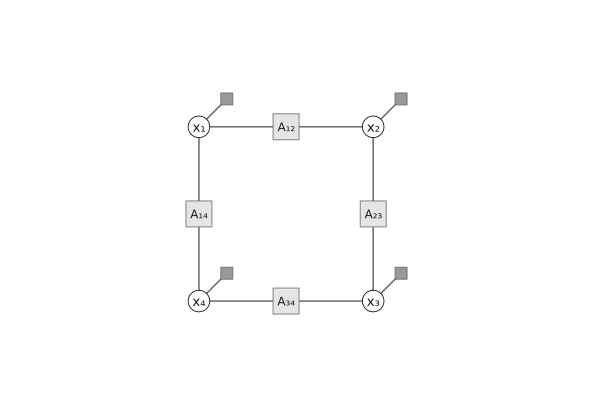

In [8]:
factor_graph(A_loop; positions = [(0.0, 1.0), (1.0, 1.0), (1.0, 0.0), (0.0, 0.0)])

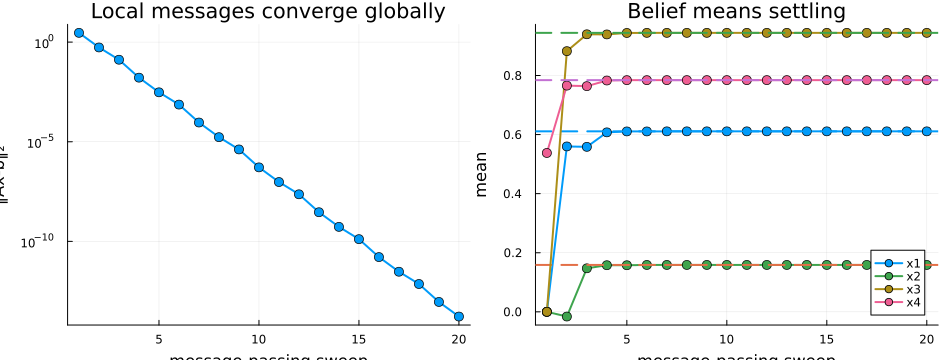

In [9]:
p_convergence = plot(
    residuals, yscale = :log10, marker = :circle, label = false,
    xlabel = "message-passing sweep", ylabel = "‖Ax-b‖₂",
    title = "Local messages converge globally",
)

p_paths = plot(
    xlabel = "message-passing sweep", ylabel = "mean",
    title = "Belief means settling",
)
for i in axes(loop.means, 1)
    plot!(p_paths, loop.means[i, :], label = "x$i", marker = :circle)
    hline!(p_paths, [x_exact_loop[i]], color = i, linestyle = :dash, label = false)
end
plot(p_convergence, p_paths; layout = (1, 2), size = (950, 360))

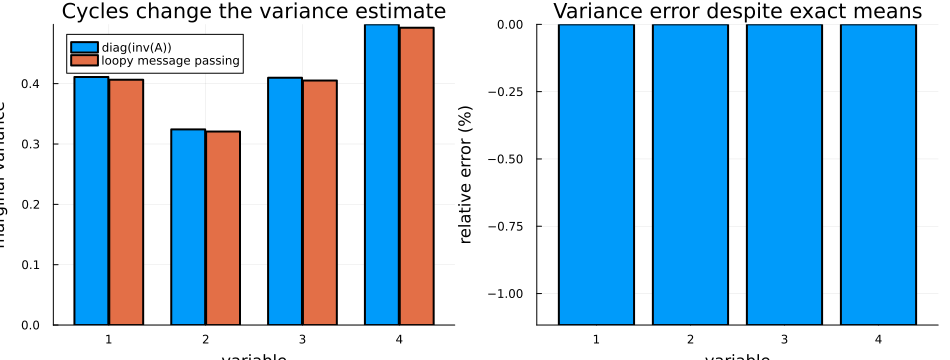

In [10]:
variance_error = 100 .* (loop.variances[:, end] .- v_exact_loop) ./ v_exact_loop

p_variances = bar(
    (1:4) .- 0.18, v_exact_loop,
    label = "diag(inv(A))", bar_width = 0.35,
    xlabel = "variable", ylabel = "marginal variance",
    title = "Cycles change the variance estimate", xticks = 1:4,
)
bar!(p_variances, (1:4) .+ 0.18, loop.variances[:, end], label = "loopy message passing", bar_width = 0.35)

p_variance_error = bar(
    1:4, variance_error, label = false,
    xlabel = "variable", ylabel = "relative error (%)",
    title = "Variance error despite exact means",
)
plot(p_variances, p_variance_error; layout = (1, 2), size = (950, 360))

## Turn up the coupling

Message passing is most comfortable when each diagonal term dominates the edges around it. The next experiment scales every off-diagonal coupling while keeping the diagonal fixed. As the system approaches the edge of diagonal dominance, information echoes more strongly around the ring and convergence slows.

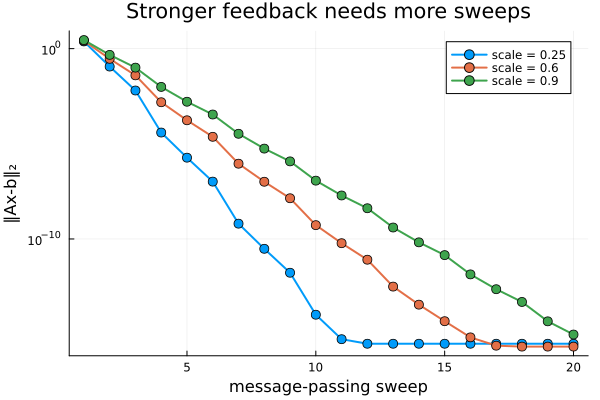

In [11]:
diagonal = Diagonal(diag(A_loop))
off_diagonal = A_loop - diagonal
coupling_scales = [0.25, 0.6, 0.9]

p_coupling = plot(
    yscale = :log10, xlabel = "message-passing sweep", ylabel = "‖Ax-b‖₂",
    title = "Stronger feedback needs more sweeps",
)
for scale in coupling_scales
    A_scaled = diagonal + scale * off_diagonal
    run = solve_with_messages(Matrix(A_scaled), b_tree; iterations = 20)
    errors = [norm(A_scaled * run.means[:, k] - b_tree) for k in axes(run.means, 2)]
    plot!(p_coupling, errors, marker = :circle, label = "scale = $scale")
end
p_coupling

## From one solve to a stream of solves: heat on a grid

So far $b$ was a fixed vector. Now let $A$ describe a $20 \times 20$ grid of cells (the discrete Laplacian plus a small leak $\kappa$ to the ambient), and let the right-hand side change over time: four segments of the boundary are in contact with the outside, two of them hot and two of them cold, and those temperatures drift. Each time step is one linear system, and the graph we already built solves all of them at once, while borrowing strength across time.

The only sensors are a thermometer at every source segment, and they occasionally go offline. When a source sensor drops out, its temperature has to be inferred from its own past and from what the other three sources are doing.


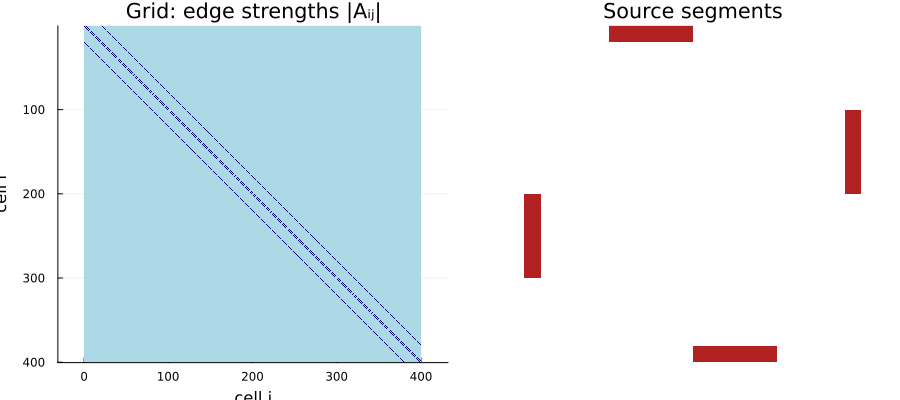

In [12]:
function grid_laplacian(m, κ)
    idx(r, c) = (r - 1) * m + c
    A = zeros(m * m, m * m)
    for r in 1:m, c in 1:m, (dr, dc) in ((1, 0), (-1, 0), (0, 1), (0, -1))
        rr, cc = r + dr, c + dc
        if 1 <= rr <= m && 1 <= cc <= m
            A[idx(r, c), idx(rr, cc)] = -1.0
            A[idx(r, c), idx(r, c)] += 1.0
        end
    end
    return A + κ * I
end

m, κ = 20, 0.1   # the leak sets how fast the sweeps settle: with κ = 0.01 the grid needs ~400 of them, with 0.1 about 50
cell(r, c) = (r - 1) * m + c
A_grid = grid_laplacian(m, κ)
n_grid = size(A_grid, 1)

source_cells = [                                                       # north, east, south, west
    [cell(1, c) for c in 6:10], [cell(r, m) for r in 6:10], [cell(m, c) for c in 11:15], [cell(r, 1) for r in 11:15],
]
K = length(source_cells)

cell_map = fill(0.0, m, m)
for i in reduce(vcat, source_cells)
    cell_map[div(i - 1, m) + 1, mod(i - 1, m) + 1] = 1.0
end
p_grid_sparsity = heatmap(
    abs.(A_grid .- Diagonal(diag(A_grid))), title = "Grid: edge strengths |Aᵢⱼ|",
    xlabel = "cell j", ylabel = "cell i", aspect_ratio = :equal, color = :blues, yflip = true, colorbar = false,
)
p_grid_cells = heatmap(
    cell_map, title = "Source segments", aspect_ratio = :equal, yflip = true,
    color = cgrad([:white, :firebrick]), clims = (0, 1), colorbar = false, framestyle = :none,
)
plot(p_grid_sparsity, p_grid_cells; layout = (1, 2), size = (900, 400))


The heat-grid factor graph has 400 unknowns, but its texture is already visible in a small patch. A $4 \times 4$ corner of the grid shows what the chain and the ring could not: every plaquette of the lattice is a loop, and neighbouring loops share edges. This is the regime where the means stay exact under convergence while the variances are genuinely approximate.

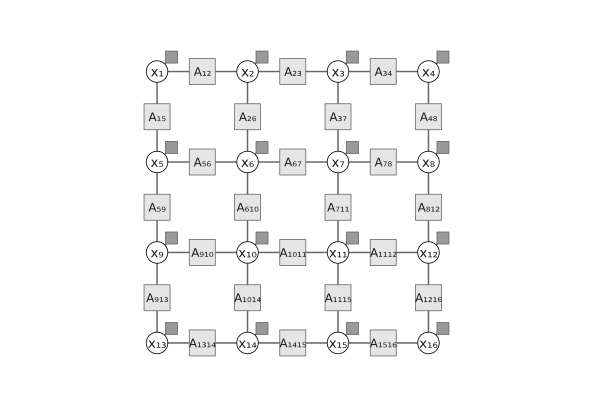

In [13]:
factor_graph(grid_laplacian(4, κ); positions = [(float(c), -float(r)) for r in 1:4 for c in 1:4])

The data are generated by a daily profile plus a slow drift that follows a random walk, one per source:

$$b_k(t) = s_k(t) + d_k(t), \qquad d_k(t) = d_k(t-1) + \varepsilon_k(t), \quad \varepsilon_k(t) \sim \mathcal{N}(0, \tau_d^{-1}).$$

The true temperature field at each step is the steady state $x_t = A^{-1} b_t$. The model below is not told the profile $s_k(t)$; it sees only the source sensors, which have precision $\tau_y$, and two of those sensors go offline for a while: entries of `Y_b` become `missing`.


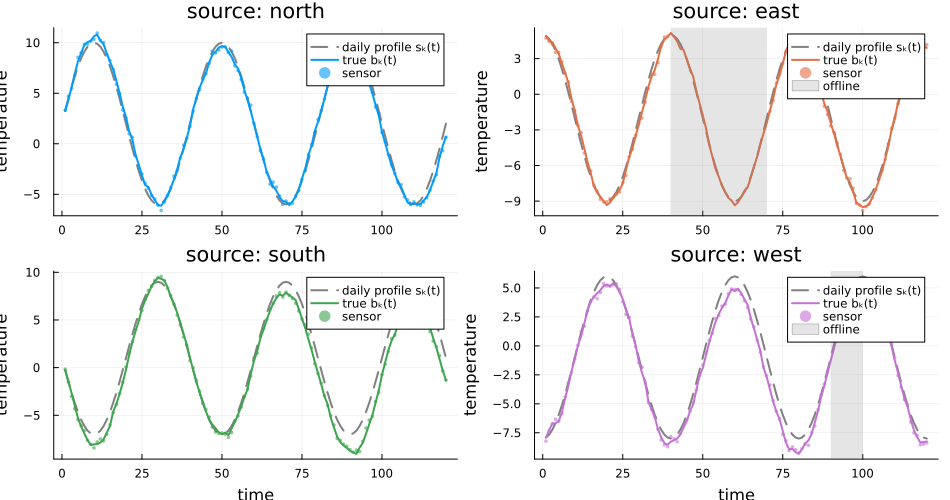

In [14]:
T, period = 120, 40
τ_d, τ_y = 25.0, 25.0   # drift, source sensors
rng = StableRNG(42)

profile_level, profile_swing, profile_phase = [2.0, -2.0, 1.0, -1.0], [8.0, 7.0, 8.0, 7.0], [0.0, π / 2, π, 3π / 2]
S_known = [profile_level[k] + profile_swing[k] * sin(2π * t / period + profile_phase[k]) for t in 1:T, k in 1:K]
D_true = cumsum(vcat(zeros(1, K), randn(rng, T - 1, K) ./ sqrt(τ_d)); dims = 1)
B_true = S_known .+ D_true

full_b(bk) = (v = zeros(n_grid); for k in 1:K; v[source_cells[k]] .= bk[k]; end; v)
X_true = reduce(hcat, (A_grid \ full_b(B_true[t, :]) for t in 1:T))'   # T × n

dropouts = Dict(2 => 40:70, 4 => 90:100)
Y_b = Matrix{Union{Float64, Missing}}(B_true .+ randn(rng, T, K) ./ sqrt(τ_y))
for (k, window) in dropouts
    Y_b[window, k] .= missing
end

source_names = ["north", "east", "south", "west"]
p_sources = plot(layout = (2, 2), size = (950, 500), legend = :topright)
for k in 1:K
    plot!(p_sources[k], 1:T, S_known[:, k], linestyle = :dash, color = :gray, label = "daily profile sₖ(t)")
    plot!(p_sources[k], 1:T, B_true[:, k], color = k, label = "true bₖ(t)")
    scatter!(p_sources[k], 1:T, Y_b[:, k], color = k, markersize = 2, markerstrokewidth = 0, alpha = 0.6, label = "sensor")
    haskey(dropouts, k) && vspan!(p_sources[k], [first(dropouts[k]), last(dropouts[k])], color = :gray, alpha = 0.2, label = "offline")
    plot!(p_sources[k], title = "source: $(source_names[k])", xlabel = k > 2 ? "time" : "", ylabel = "temperature")
end
p_sources


### A state-space prior for the sources

Before wiring the sources into the grid, give them a prior of their own. The four temperatures at time $t$ form one vector $b_t$ that follows a random walk with an unknown $4 \times 4$ transition precision $\Lambda \sim \mathrm{Wishart}$: the sources drift together or apart, and $\Lambda$ learns how. Each sensor is a scalar reading of one component, $\langle b_t, e_k \rangle$, with a learned precision $\tau$, so a single `missing` entry drops one likelihood term instead of a whole time slice.

We write this as a *submodel*. The arguments of a `@model` are its Markov blanket, the variables it shares with the outside: `y_b` (the data), `b` (the states it creates), `Λ` and `τ` (hyperparameters owned by the caller) and the constant `dim_latent`. Everything else stays internal. A submodel is invoked with `~`: all but one interface are given by keyword and the remaining one is bound to the left-hand side, so `b ~ lss_prior(y_b = y_b, Λ = Λ, τ = τ, dim_latent = 4)` hands the whole array of states back to the caller. Factorisation constraints for the factors inside a submodel live in a `for q in lss_prior` block. First we run it on its own, wrapped in a top-level model that declares $\Lambda$ and $\tau$.


In [16]:
unit(k, n) = onehot(k, 1:n)  # eₖ as a plain vector, so dot(b[t], eₖ) picks component k

@model function lss_prior(y_b, b, Λ, τ, dim_latent)
    b[1] ~ MvNormalMeanPrecision(zeros(dim_latent), 0.01 * diageye(dim_latent))
    for t in 1:size(y_b, 1)
        if t > 1
            b[t] ~ MvNormalMeanPrecision(b[t - 1], Λ)
        end
        for k in 1:dim_latent
            y_b[t, k] ~ NormalMeanPrecision(dot(b[t], unit(k, dim_latent)), τ)
        end
    end
end

@model function linear_state_space_model(y_b, dim_latent)
    Λ ~ Wishart(dim_latent + 2, diageye(dim_latent))
    τ ~ GammaShapeRate(1, 1)
    b ~ lss_prior(y_b = y_b, Λ = Λ, τ = τ, dim_latent = dim_latent)
end

lss_constraints = @constraints begin
    for q in lss_prior
        q(b, Λ, τ) = q(b)q(Λ)q(τ)
    end
end

lss_init = @initialization begin
    q(Λ) = Wishart(K + 2, diageye(K))
    q(τ) = GammaShapeRate(1.0, 1.0)
end

lss_result = infer(
    model = linear_state_space_model(dim_latent = K),
    data = (y_b = Y_b,),
    constraints = lss_constraints,
    initialization = lss_init,
    returnvars = (b = KeepLast(), Λ = KeepLast(), τ = KeepLast()),
    options = (limit_stack_depth = 100,),
    iterations = 10,
)

B_lss_mean = reduce(hcat, mean.(lss_result.posteriors[:b]))'   # T × 4
B_lss_std = reduce(hcat, (sqrt.(var(q)) for q in lss_result.posteriors[:b]))'
observed = .!ismissing.(Y_b)
println("max error on observed entries: ", maximum(abs.(B_lss_mean[observed] .- B_true[observed])))
println("max error on missing entries:  ", maximum(abs.(B_lss_mean[.!observed] .- B_true[.!observed])))
println("learned sensor precision: ", mean(lss_result.posteriors[:τ]), "  (true τ_y = ", τ_y, ")")


max error on observed entries: 0.5252585205970179
max error on missing entries:  1.3195610913317282
learned sensor precision: 17.01086936024023  (true τ_y = 25.0)


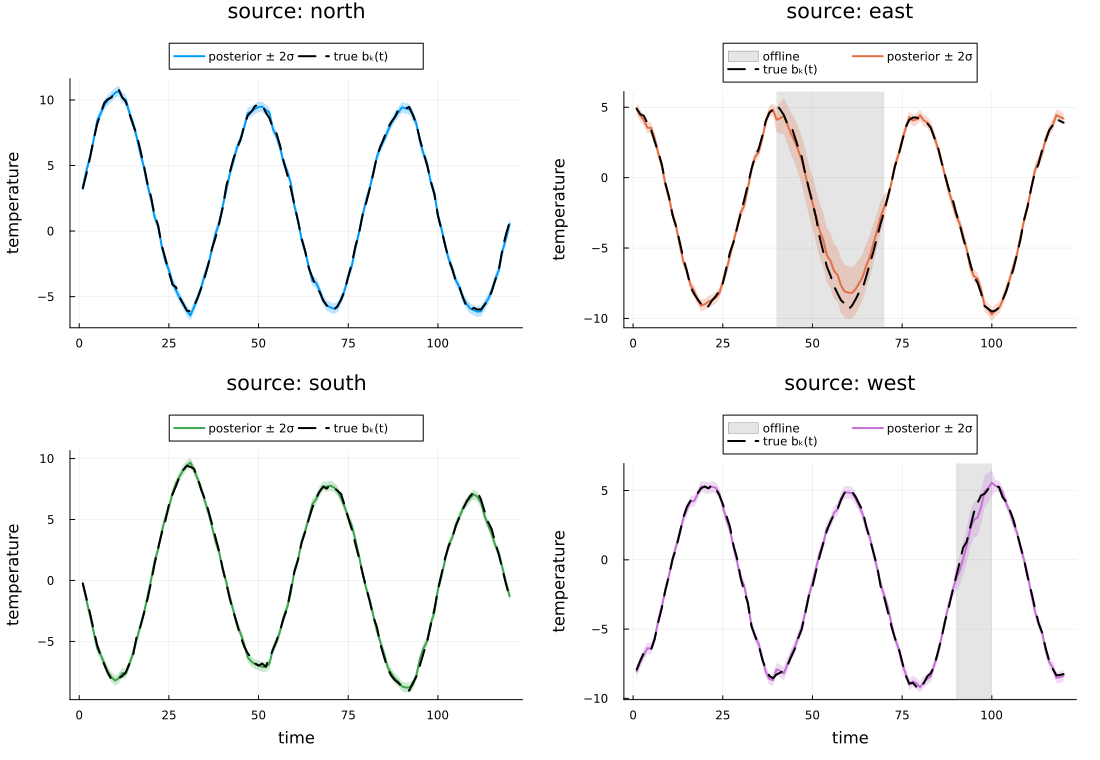

In [17]:
p_lss = plot(layout = (2, 2), size = (1100, 760), legend = :outertop, legend_columns = 2, margin = 4Plots.mm)
for k in 1:K
    haskey(dropouts, k) && vspan!(p_lss[k], [first(dropouts[k]), last(dropouts[k])], color = :gray, alpha = 0.2, label = "offline")
    plot!(p_lss[k], 1:T, B_lss_mean[:, k], ribbon = 2 .* B_lss_std[:, k], color = k, fillalpha = 0.25, label = "posterior ± 2σ")
    plot!(p_lss[k], 1:T, B_true[:, k], color = :black, linestyle = :dash, label = "true bₖ(t)")
    plot!(p_lss[k], title = "source: $(source_names[k])", xlabel = k > 2 ? "time" : "", ylabel = "temperature")
end
p_lss


While a sensor is offline the state-space prior carries the source on its own past and on the learned coupling $\Lambda$ to the other three sources; the uncertainty grows, but stays bounded. Now the same submodel goes into the grid.


### The model

Each time slice is the linear system from the first half, scaled by an inverse temperature $\beta$. Multiplying both $A$ and $b$ by $\beta$ leaves the solution $A^{-1}b$ untouched, but changes the covariance to $(\beta A)^{-1}$: $\beta$ says how tightly the field is expected to follow the steady-state equation. Interior cells keep the Gaussian self-potential of `linear_system_model` with $b_i = 0$, written with a static right-hand side `b0` of zeros. The source cells are driven by the state instead: all cells of segment $k$ share the temperature $\langle b_t, e_k \rangle$, and the coupling $\exp(\beta\, b_{t,k} x_i)$ is one `GaussianCoupling` node between that temperature and each cell of the segment. The prior on $b_t$ is the submodel from the previous section, plugged in with one line. Its hyperparameters are not learned a second time: the first loopy sweeps through the grid send wild messages to the sources, and a variational update of $\tau$ or $\Lambda$ that sees them collapses to zero and never recovers. The posterior means from the standalone run go in as constants instead, through the same two interfaces. The field itself has no dynamics of its own: every slice is the steady state for its sources, exactly as in the data, and all memory lives in $b_t$.

One subtlety of the potential remains. $\exp(b^\mathsf{T}x - \frac{1}{2}x^\mathsf{T}Ax)$ integrates over $x$ to $\exp(\frac{1}{2}b^\mathsf{T}A^{-1}b)$ up to a constant. When $b$ is data this is irrelevant; when $b$ is latent it is a *negative* precision $\beta\, M^\mathsf{T}A^{-1}M$ on the segment temperatures ($M$ is the cell-to-segment indicator), about $8\beta$ per segment on this grid. Cancelling it exactly would need $A^{-1}M$, four extra solves. We keep it instead and make it harmless by keeping $\beta$ small. While a sensor is online its precision of $25$ swamps the pull. During a long dropout the source is held only by the random walk, whose slowest mode over a gap of $L$ steps has precision about $\Lambda\pi^2/(L+1)^2 \approx 0.1$ for the 31-step outage; the pull has to stay well below that, otherwise the posterior on the blind source is no longer proper and the sweeps diverge. $\beta = 0.003$ puts the pull at $0.025$: the field is still solved exactly, since $\beta$ only rescales the potential, and the price is a slightly wider error during the outage.


In [18]:
@model function heat_grid_model(y_b, b0, A, β, Λ, τ, source_cells)
    T, n, K = size(y_b, 1), size(A, 1), length(source_cells)
    local x, bs   # declared once so all loops below refer to the same variables

    # The state-space prior on the sources, with the sensor likelihood inside it.
    # Λ and τ are plain matrices/numbers here: the interfaces accept constants as well as variables.
    b ~ lss_prior(y_b = y_b, Λ = Λ, τ = τ, dim_latent = K)

    for t in 1:T
        # The linear system at time t, exactly as before, scaled by β.
        for i in 1:n
            x[t, i] ~ Normal(mean = b0[i] / A[i, i], precision = β * A[i, i])
        end
        # Every cell of segment k is driven by component k of the state.
        for k in 1:K
            bs[t, k] := dot(b[t], unit(k, K))
            for i in source_cells[k]
                x[t, i] ~ GaussianCoupling(bs[t, k], β)
            end
        end
        for i in 1:(n - 1), j in (i + 1):n
            if !iszero(A[i, j])
                x[t, j] ~ GaussianCoupling(x[t, i], -β * A[i, j])
            end
        end
    end
end


The graph has loops within each time slice and a chain across time for the sources, so we again start from broad messages, on the field `x` and on the segment temperatures `bs`. With $\Lambda$ and $\tau$ fixed the whole model is Gaussian and no factorisation constraints are needed.


In [19]:
β = 0.003    # inverse temperature of the linear-system potential; see the note on the normaliser above

Λ_hat = mean(lss_result.posteriors[:Λ])   # plug-in hyperparameters from the standalone run
τ_hat = mean(lss_result.posteriors[:τ])

grid_init = @initialization begin
    μ(x) = NormalMeanVariance(0.0, 1e6)
    μ(bs) = NormalMeanVariance(0.0, 1e6)
end

grid_result = infer(
    model = heat_grid_model(A = A_grid, β = β, Λ = Λ_hat, τ = τ_hat, source_cells = source_cells),
    data = (y_b = Y_b, b0 = zeros(n_grid)),
    initialization = grid_init,
    returnvars = (x = KeepLast(), b = KeepLast()),
    options = (limit_stack_depth = 100,),   # the graph is deep: 120 slices × 400 cells
    iterations = 10,
)

x_post = grid_result.posteriors[:x]   # T × n matrix of beliefs
b_post = grid_result.posteriors[:b]   # T beliefs over the 4-vector of source temperatures
X_mean, X_std = mean.(x_post), std.(x_post)
B_mean = reduce(hcat, mean.(b_post))'                    # T × 4
B_std = reduce(hcat, (sqrt.(var(q)) for q in b_post))'   # T × 4
println("largest deviation of the posterior mean from the true field: ", maximum(abs.(X_mean - X_true)))
println("all variances proper: ", all(>(0), var.(x_post)) && all(q -> all(>(0), var(q)), b_post))


largest deviation of the posterior mean from the true field: 2.8445911724100705
all variances proper: true


### Sources recovered through the grid

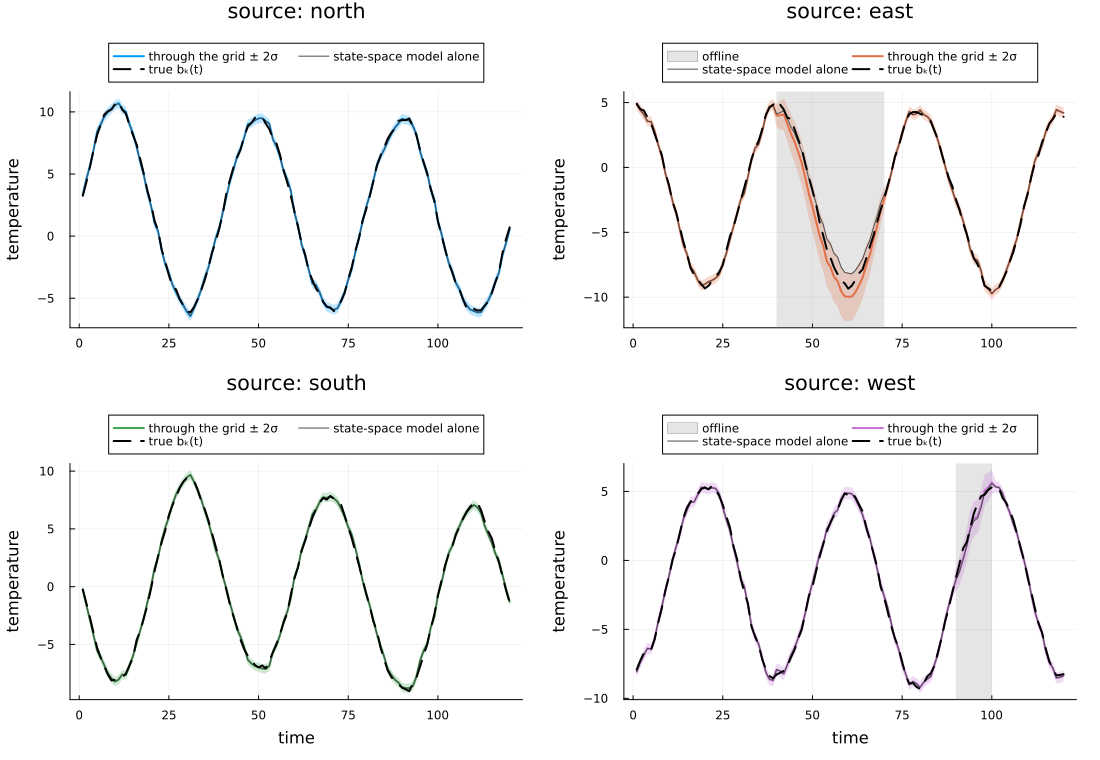

In [20]:
p_grid_sources = plot(layout = (2, 2), size = (1100, 760), legend = :outertop, legend_columns = 2, margin = 4Plots.mm)
for k in 1:K
    haskey(dropouts, k) && vspan!(p_grid_sources[k], [first(dropouts[k]), last(dropouts[k])], color = :gray, alpha = 0.2, label = "offline")
    plot!(p_grid_sources[k], 1:T, B_mean[:, k], ribbon = 2 .* B_std[:, k], color = k, fillalpha = 0.25, label = "through the grid ± 2σ")
    plot!(p_grid_sources[k], 1:T, B_lss_mean[:, k], color = :gray30, linewidth = 1, label = "state-space model alone")
    plot!(p_grid_sources[k], 1:T, B_true[:, k], color = :black, linestyle = :dash, label = "true bₖ(t)")
    plot!(p_grid_sources[k], title = "source: $(source_names[k])", xlabel = k > 2 ? "time" : "", ylabel = "temperature")
end
p_grid_sources


The estimates follow the state-space model alone closely. With no thermometers inside the plate the field has nothing of its own to say about the sources; the only route back from the grid is the un-cancelled normaliser, which does nothing while the sensors are online and, during the long outage, pushes the blind source a little further away from zero than the random walk alone would (here that happens to land closer to the truth, but it is a bias, not information). What the grid adds is the field: every slice is solved together with the sources, dropouts included.

### Are the numbers right?

The whole model is one big sparse Gaussian with $120 \times (400 + 4)$ variables. Its exact posterior would need a dense $48\,000 \times 48\,000$ solve, which is exactly the kind of computation message passing lets us avoid. On the earlier small examples we saw that Gaussian message passing returns exact means and slightly optimistic variances on loopy graphs, and the same holds here: the posterior mean tracks the true field while the sensors are online, and the uncertainty around a source grows only while its sensor is offline.


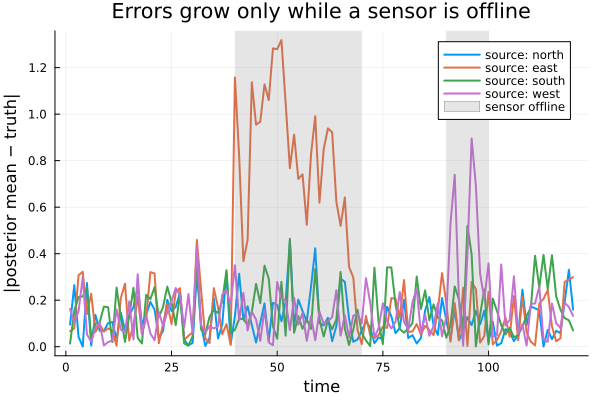

In [21]:
p_field_error = plot(xlabel = "time", ylabel = "|posterior mean − truth|", title = "Errors grow only while a sensor is offline")
for k in 1:4
    plot!(p_field_error, 1:T, abs.(B_mean[:, k] - B_true[:, k]), color = k, label = "source: $(source_names[k])")
end
for (k, window) in dropouts
    vspan!(p_field_error, [first(window), last(window)], color = :gray, alpha = 0.2, label = k == 2 ? "sensor offline" : false)
end
p_field_error

### The field, live

Finally, the whole picture in motion: the true temperature field, the posterior mean, where the two differ, and how far the posterior standard deviation of every cell rises above its level when all sensors are online, with the source temperatures below. The absolute standard deviation is dominated by the field noise $(\beta A)^{-1}$ and barely changes in time; the increase caused by a blind sensor is small but spreads from that wall into the plate. Thick bars mark the source segments, red while their sensor is offline. As the day goes on, the hot and cold spots rotate around the grid.


In [22]:
to_grid(v) = reshape(v, m, m)'   # row r, column c  ↔  cell(r, c)
rc(i) = (div(i - 1, m) + 1, mod(i - 1, m) + 1)
interior = setdiff(1:n_grid, reduce(vcat, source_cells))
temp_max = sort(abs.(vec(X_true[:, interior])))[round(Int, 0.98 * end)]   # let the hottest cells saturate
temp_lims = (-temp_max, temp_max)
X_err = abs.(X_mean - X_true)
err_lims = (0.0, sort(vec(X_err))[round(Int, 0.995 * end)])
X_extra_std = X_std .- minimum(X_std; dims = 1)   # how much each cell's std rises above its all-sensors-online level
std_lims = (0.0, maximum(X_extra_std))

function field_panel(values, title; clims, color)
    p = heatmap(values; title, clims, color, aspect_ratio = :equal, yflip = true, framestyle = :none, colorbar = true, titlefontsize = 11)
    return p
end

function mark_cells!(p, t)
    for (k, cells) in enumerate(source_cells)
        offline = haskey(dropouts, k) && t in dropouts[k]
        plot!(p, last.(rc.(cells)), first.(rc.(cells)), color = offline ? :red : :black, linewidth = offline ? 5 : 3, label = false)
    end
    return p
end

function field_frame(t)
    offline = count(k -> t in dropouts[k], keys(dropouts))
    p_true = mark_cells!(field_panel(to_grid(X_true[t, :]), "true temperature"; clims = temp_lims, color = cgrad(:RdBu, rev = true)), t)
    p_mean = mark_cells!(field_panel(to_grid(X_mean[t, :]), "posterior mean"; clims = temp_lims, color = cgrad(:RdBu, rev = true)), t)
    p_err  = mark_cells!(field_panel(to_grid(X_err[t, :]), "|posterior mean − truth|"; clims = err_lims, color = :viridis), t)
    p_std  = mark_cells!(field_panel(to_grid(X_extra_std[t, :]), "std above online baseline"; clims = std_lims, color = :viridis), t)
    p_b = plot(legend = :outertop, legend_columns = 4, xlabel = "time", ylabel = "source temperature", xlims = (1, T), ylims = (-12, 12), left_margin = 6Plots.mm)
    for (k, window) in dropouts
        vspan!(p_b, [first(window), last(window)], color = :gray, alpha = 0.15, label = false)
    end
    for k in 1:K
        plot!(p_b, 1:t, B_mean[1:t, k], ribbon = 2 .* B_std[1:t, k], color = k, fillalpha = 0.2, label = source_names[k])
        plot!(p_b, 1:t, B_true[1:t, k], color = k, linestyle = :dot, linewidth = 1, label = false)
    end
    vline!(p_b, [t], color = :black, linewidth = 1, label = false)
    plot(p_true, p_mean, p_err, p_std, p_b; layout = @layout([a b c d; e{0.42h}]), size = (1300, 580), margin = 2Plots.mm, bottom_margin = 5Plots.mm,
         plot_title = "t = $t   ·   $offline sensor(s) offline", plot_titlefontsize = 12)
end

anim = @animate for t in [1:T; fill(T, 12)]
    field_frame(t)
end
gif(anim, "heat-grid-filter.gif", fps = 6, show_msg = false);

![](heat-grid-filter.gif)

A single frame from the middle of the first outage:

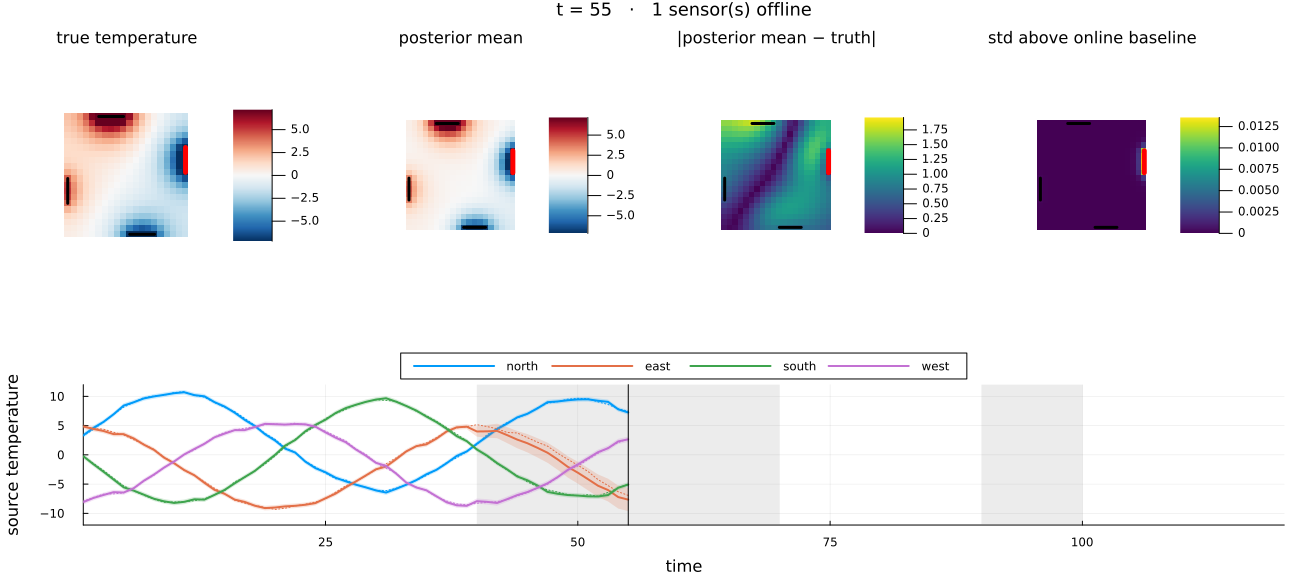

In [23]:
field_frame(55)

## Takeaways

- `GaussianCoupling(x[i], -A[i, j])` turns a matrix off-diagonal into a pairwise Gaussian coupling.
- Sparse matrices become sparse factor graphs, and local message updates recover the global solution.
- Loopy graphs need initial messages; `μ(x) = NormalMeanVariance(0, 1e6)` is a neutral broad starting point.
- Under suitable convergence conditions, the means solve $Ax=b$ exactly.
- Variances are exact on trees, but generally approximate on graphs with cycles.
- The same graph solves a whole sequence of systems: give $b$ a temporal prior, feed it observations (missing ones included) and message passing turns into a smoother over time.
- A prior written as a submodel is reused with one `~` line; its hyperparameters go on the Markov blanket, so the caller decides whether they are learned (with constraints scoped by `for q in submodel`) or plugged in as constants.
- When $b$ becomes latent, the normaliser of $\exp(b^\mathsf{T}x - \frac{1}{2}x^\mathsf{T}Ax)$ turns into a negative precision on $b$ that scales with $\beta$. It only matters where the data go quiet: keep $\beta$ small enough that the temporal prior still dominates during the longest dropout, and $A^{-1}$ is never needed.

For production linear solves, Julia's specialized factorizations remain the natural default. The message-passing formulation becomes interesting when the graph is distributed, when local updates matter, or when the linear system is one component of a larger probabilistic model.
